In [5]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load JSON file
with open("out.json", "r") as f:
    data = json.load(f)


# Convert to DataFrame
df = pd.DataFrame(data)

print("JSON file loaded successfully!")

JSON file loaded successfully!


In [6]:
df.head()

,input_seq_len,output_seq_len,shift,MSE
0,24,12,12,0.194278
1,24,12,16,0.156330
2,24,24,12,0.202760
3,24,24,16,0.234041
4,48,12,12,0.134555


In [7]:
for input_seq_len in df["input_seq_len"].unique():
    for output_seq_len in df["output_seq_len"].unique():
        for shift in df["shift"].unique():
                mse = df[(df["input_seq_len"]==input_seq_len) & (df["output_seq_len"]==output_seq_len) & (df["shift"]==shift)]['MSE'].values[0]
                print(f"input_seq_len:{input_seq_len} - output_seq_len: {output_seq_len} --> MSE = {mse:.3f}")


input_seq_len:24 - output_seq_len: 12 --> MSE = 0.194
input_seq_len:24 - output_seq_len: 12 --> MSE = 0.156
input_seq_len:24 - output_seq_len: 24 --> MSE = 0.203
input_seq_len:24 - output_seq_len: 24 --> MSE = 0.234
input_seq_len:48 - output_seq_len: 12 --> MSE = 0.135
input_seq_len:48 - output_seq_len: 12 --> MSE = 0.169
input_seq_len:48 - output_seq_len: 24 --> MSE = 0.189
input_seq_len:48 - output_seq_len: 24 --> MSE = 0.197


In [4]:
subset = df[df["shift"] == 12]
subset

,input_seq_len,output_seq_len,shift,MSE
0,24,12,12,0.194278


In [5]:
next(iter(subset.groupby("input_seq_len")))

(24,
    input_seq_len  output_seq_len  shift       MSE
 0             24              12     12  0.194278)

/var/folders/66/rpqcrym93h90yphhq7kgwhb00000gn/T/ipykernel_11153/1254072752.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(df["input_seq_len"].unique()))


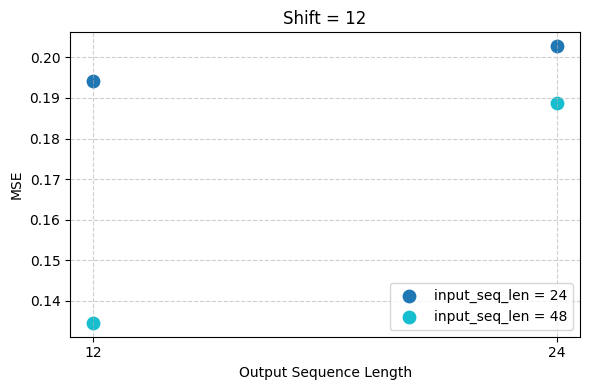

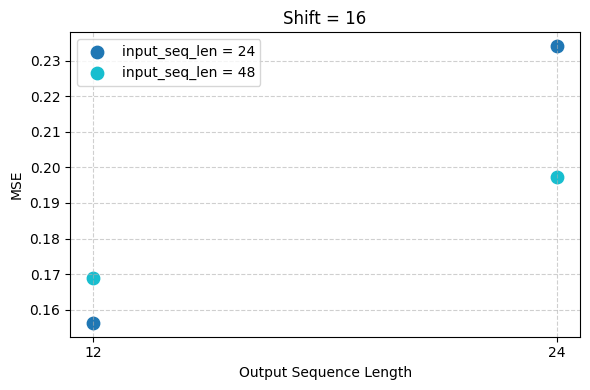

In [8]:
# Create a scatter plot for each value of shift 
shifts = sorted(df["shift"].unique())
colors = plt.cm.get_cmap("tab10", len(df["input_seq_len"].unique()))

for i, shift_val in enumerate(shifts):
    subset = df[df["shift"] == shift_val]
    plt.figure(figsize=(6, 4))
    
    # Plot one color per input_seq_len
    for j, (input_val, subsub) in enumerate(subset.groupby("input_seq_len")):
        plt.scatter(
            subsub["output_seq_len"],
            subsub["MSE"],
            label=f"input_seq_len = {input_val}",
            color=colors(j),
            s=80
        )

    plt.title(f"Shift = {shift_val}")
    plt.xlabel("Output Sequence Length")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    
    x_min, x_max = df["output_seq_len"].min(), df["output_seq_len"].max()
    plt.xticks(np.arange(x_min, x_max + 12, 12))

    plt.tight_layout()
    plt.show()
    


    